In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/cleaned/customer_clean.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
from sklearn.preprocessing import MinMaxScaler

In [4]:
scaler = MinMaxScaler()

In [5]:
df[["TenureScore"]] = scaler.fit_transform(
    df[["tenure"]]
)

df[["MonthlyScore"]] = scaler.fit_transform(
    df[["MonthlyCharges"]]
)

df[["TotalScore"]] = scaler.fit_transform(
    df[["TotalCharges"]]
)

In [6]:
df["CustomerScore"] = (
      0.4 * df["TenureScore"]
    + 0.2 * df["MonthlyScore"]
    + 0.4 * df["TotalScore"]
)

In [7]:
df["CustomerScore"] = (
    df["CustomerScore"] * 100
)

In [8]:
df["CustomerScore"].describe()

count    7043.000000
mean       37.739911
std        26.235907
min         0.288557
25%        15.311870
50%        32.631600
75%        57.410476
max        99.943119
Name: CustomerScore, dtype: float64

In [9]:
def segment_customer(score):

    if score >= 80:
        return "Champion"

    elif score >= 60:
        return "Loyal"

    elif score >= 40:
        return "Potential Loyalist"

    elif score >= 20:
        return "At Risk"

    else:
        return "Lost"

In [10]:
df["Segment"] = df["CustomerScore"].apply(
    segment_customer
)

In [11]:
df["Segment"].value_counts()

Segment
Lost                  2350
At Risk               1768
Potential Loyalist    1294
Loyal                  992
Champion               639
Name: count, dtype: int64

In [14]:
df.groupby("Segment")[
    ["tenure",
     "MonthlyCharges",
     "TotalCharges"]
].mean().round(2)

,tenure,MonthlyCharges,TotalCharges
Segment,,,
At Risk,26.57,61.86,1314.20
Champion,68.78,103.34,7110.56
Lost,6.92,46.74,252.17
Loyal,59.28,86.54,5031.12
Potential Loyalist,47.91,65.71,2786.35


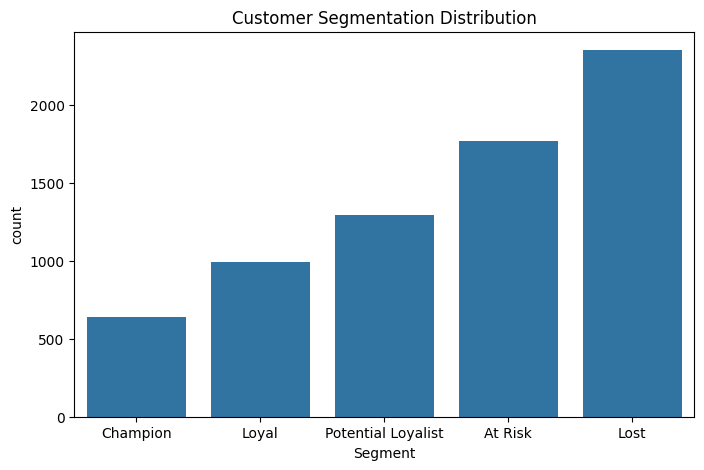

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Segment",
    data=df,
    order=[
        "Champion",
        "Loyal",
        "Potential Loyalist",
        "At Risk",
        "Lost"
    ]
)

plt.title("Customer Segmentation Distribution")
plt.show()

# Customer Segmentation Results

The customer base was segmented using a custom Customer Score derived from tenure, monthly charges, and total charges.

Key Findings:

- Champion customers represent the most valuable and loyal segment.
- Loyal customers contribute stable recurring revenue.
- Potential Loyalists represent growth opportunities.
- At Risk customers require proactive retention efforts.
- Lost customers have the lowest engagement and value scores.

The segmentation framework enables targeted business strategies instead of treating all customers identically.